# Lecture 3 demo: ML fundamentals

Varada Kolhatkar

# Lecture 3 Class Demo

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
RANDOM_STATE = 123

Let's use housing prices to investigate a question from last lecture: **does a great training score mean we have a useful model?**

We'll build a first model, question how we evaluated it, and improve our workflow together. The opening steps are deliberately naive: we explore and fit on all the data before introducing splitting. By the end, we'll explain what we would do differently on a fresh project.

**How to use this notebook:** pause at the questions before running the next cell. Code cells marked `TODO` contain the worked solution for now; try describing or writing your approach before reading it. You can hide the solution while we work together.

Run cells in order in JupyterLab or VS Code. Put `kc_house_data.csv` in a `data` folder beside this notebook, and use a kernel with NumPy, pandas, Matplotlib, and scikit-learn installed.

[Chapter 3: ML fundamentals](https://ubc-cs.github.io/cpsc330-book/book/03_ml-fundamentals.html)

## The prediction problem

The King County housing dataset contains records of house sales, including sale prices and information about each property. The data are available from [House Sales in King County, USA](https://www.kaggle.com/harlfoxem/housesalesprediction). 

Imagine that we want to estimate a property's sale price from its recorded characteristics.

In [2]:
data_path = Path("data/kc_house_data.csv")

housing_df = pd.read_csv(data_path)
housing_df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


### ❓❓ Questions for you

**Discuss before coding**

- What does one example represent? What is the target?
- Is this a classification problem or a regression problem?
- What would it mean for this model to generalize?

## Exploratory Data Analysis (EDA)

Before building anything, let's get to know these house sales.

**TODO: take a first look.** How many rows and columns do we have? What do the summaries and missing-value counts tell us?

We're using the full dataset in this opening demonstration. On a fresh project, we would reserve test data **before EDA**. Keep track of this shortcut—we'll return to it at the end.

In [3]:
# How many data points do we have? 
housing_df.shape[0]

21613

In [4]:
# What are the columns in the dataset? 
housing_df.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='str')

What ranges do the numerical features have? Let's try `describe()` and `info()`. 

In [5]:
housing_df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [6]:
housing_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

Does a numerical dtype always mean a column should be treated as a numerical measurement?

In [7]:
# TODO: check whether any columns have missing values.
housing_df.isna().sum()


id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

### Which columns should we use?

Let's discuss what each column represents, not just whether Python can accept it.

In [8]:
housing_df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


**Would `id` help predict a new property's price?** Compare the number of distinct IDs with the number of sales. Could a property appear more than once?

In [9]:
housing_df['id'].unique().shape[0]

21436

**What could we learn from `date`?** Would passing this raw string to a tree work?

In [10]:
housing_df['date']

0        20141013T000000
1        20141209T000000
2        20150225T000000
3        20141209T000000
4        20150218T000000
              ...       
21608    20140521T000000
21609    20150223T000000
21610    20140623T000000
21611    20150116T000000
21612    20141015T000000
Name: date, Length: 21613, dtype: str

In [11]:
dates = pd.to_datetime(['20141013T000000', '20141209T000000', '20150218T000000'], format='%Y%m%dT%H%M%S')
dates.month_name()

Index(['October', 'December', 'February'], dtype='str')

**Could location help?** A ZIP code contains location information, but does a larger code mean 'more' of something?

In [12]:
housing_df['zipcode']

0        98178
1        98125
2        98028
3        98136
4        98074
         ...  
21608    98103
21609    98146
21610    98144
21611    98027
21612    98144
Name: zipcode, Length: 21613, dtype: int64

**What do you expect from `waterfront`?** Check its value counts. How common are waterfront properties?

In [13]:
# What are the value counts of the `waterfront` feature? 
housing_df['waterfront'].value_counts()

waterfront
0    21450
1      163
Name: count, dtype: int64

In [14]:
# What are the value_counts of `yr_renovated` feature? 
housing_df['yr_renovated'].value_counts()

yr_renovated
0       20699
2014       91
2013       37
2003       36
2005       35
        ...  
1948        1
1951        1
1959        1
1934        1
1944        1
Name: count, Length: 70, dtype: int64

For today, we'll omit `id`, `date`, and `zipcode` to focus on evaluation. This is a teaching simplification, not a claim that dates or location are useless. We'll revisit feature preparation later.

### Your turn: separate inputs and target

**TODO:** create `X` without the target and the three omitted columns, and create `y` from `price`. Why must `price` stay out of `X`?

In [15]:
# TODO: try this step before reading the worked solution below.
X = housing_df.drop(columns = ['id', 'date', 'zipcode', 'price'])

In [16]:
# TODO: try this step before reading the worked solution below.
y = housing_df['price']

## A baseline: predict the same price for every house

**Before running:** if you had to predict one price for everyone, what would you choose?

**TODO:** fit a `DummyRegressor` on `X, y`, inspect a few predictions, and score it on those same data. We have no validation set yet: this is a **training score**.

For these regressors, `.score()` returns **R², not accuracy**. Higher is better: 1 is perfect; 0 matches predicting the mean target of the evaluated data; negative values are possible. A baseline fitted on another subset need not score exactly 0 on held-out data.

In [17]:
# TODO: try this step before reading the worked solution below.
# Train a DummyRegressor model 

from sklearn.dummy import DummyRegressor # Import DummyRegressor 

# Create a class object for the sklearn model.
dummy_regr = DummyRegressor()

# fit the dummy regressor
dummy_regr.fit(X, y)

# score the model 
dummy_regr.score(X, y)


0.0

**Pause:** why is this training score approximately zero? Does that mean none of the predicted prices are useful?

In [18]:
dummy_regr.predict(X.iloc[:5])

array([540088.14176653, 540088.14176653, 540088.14176653, 540088.14176653,
       540088.14176653])

## Can a decision tree do better?

**Predict first:** will its training score be higher than the baseline's?

**TODO:** fit an unrestricted `DecisionTreeRegressor` on `X, y` and score it on the same examples.

In [19]:
# TODO: try this step before reading the worked solution below.
# Train a decision tree model 

from sklearn.tree import DecisionTreeRegressor # Import DecisionTreeRegressor 

# Create a class object for the sklearn model.
dt_regr = DecisionTreeRegressor(random_state=RANDOM_STATE)

# fit the decision tree regressor 
dt_regr.fit(X, y)

# score the model 
dt_regr.score(X, y)

0.9991338290544213

### Intuition of regression trees

- In classification trees, a "good split" is one that makes each group more pure in terms of labels (e.g., mostly happy 🙂 vs. mostly unhappy 🙁).
- In regression trees, a good split is one that creates groups where the target values have low variance around their mean.

See [the documentation](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html) for more details. 

### Stop and discuss

Our training score looks impressive. **Would you deploy this model?**

- Which examples did the model see during fitting?
- Have we measured performance on any unseen examples?
- What evidence would make you more confident?

What's the depth of this model? 

In [20]:
dt_regr.get_depth()

38

## Data splitting 

Our first score answered, 'How well can the model fit data it has already seen?' We want to ask, **'How well will it predict new examples?'**

**Slide pause:** connect training, validation, test, and deployment to practice questions, held-out practice questions, the exam, and interview questions.

**TODO:** split `X, y` into 80% training and 20% test data. Fit a **fresh** tree on training data only.

This keeps the new fit separate from the held-out rows, but does not undo our earlier full-data exploration. We'll use this split to learn the mechanics; it is not a pristine final assessment.

In [21]:
# TODO: try this step before reading the worked solution below.
# Split the data 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

In [22]:
X.shape, X_train.shape, X_test.shape

((21613, 17), (17290, 17), (4323, 17))

In [23]:
# Instantiate a class object 
dt = DecisionTreeRegressor(random_state=RANDOM_STATE)

# Train a decision tree on X_train, y_train
dt.fit(X_train, y_train)

# Score on the train set
dt.score(X_train, y_train)

0.9994394006711425

In [24]:
# Score on the test set
dt.score(X_test, y_test)

0.719915905190645

### What changed?

- How do the training and held-out scores compare? What could explain the gap?
- What do we gain and lose by reserving a larger test set?
- Why fix `random_state`? Would searching for a favourable split improve the model or just its reported score?

**TODO:** also fit the dummy baseline on training data only. Compare its training and held-out scores with the tree's.

In [25]:
# Compare with a baseline fitted only on the training subset.
dummy_split = DummyRegressor().fit(X_train, y_train)
pd.DataFrame({
    "train_score": [dummy_split.score(X_train, y_train), dt.score(X_train, y_train)],
    "held_out_score": [dummy_split.score(X_test, y_test), dt.score(X_test, y_test)],
}, index=["Dummy regressor", "Decision tree"])


,train_score,held_out_score
Dummy regressor,0.000000,-0.000108
Decision tree,0.999439,0.719916


## Does limiting depth help?

**Predict first:** what will happen to both scores if we allow only one split?

**TODO:** fit a decision stump and inspect its split. We're about to try model choices against the test set—watch for the evaluation problem this creates.

In [26]:
# TODO: try this step before reading the worked solution below.
# max_depth= 1 
dt = DecisionTreeRegressor(max_depth=1, random_state=RANDOM_STATE) 
dt.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",123
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes ma

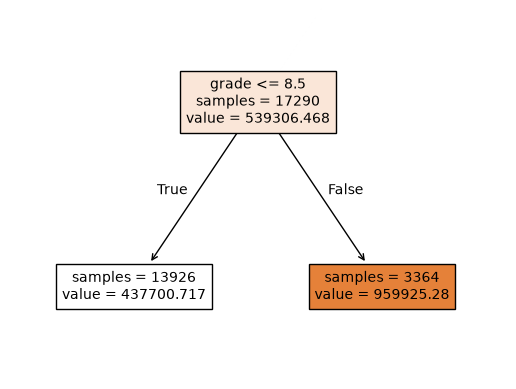

In [27]:
# Visualize your decision stump
from sklearn.tree import plot_tree 
plot_tree(dt, feature_names = X.columns.tolist(), impurity=False, filled=True, fontsize=10);

In [28]:
dt.score(X_train, y_train) # Score on the train set

0.3209427041566191

In [29]:
dt.score(X_test, y_test) # Score on the test set

0.31767136668453344

**Discuss:** are both scores poor, or is only the held-out score poor? What would support calling this underfitting?

Now allow `max_depth=20`. **Predict before running:** must both scores improve?

In [30]:
dt = DecisionTreeRegressor(max_depth=20, random_state=RANDOM_STATE)
dt.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",20
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",123
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes m

In [31]:
dt.score(X_train, y_train) # Score on the train set

0.9968347348881582

In [32]:
dt.score(X_test, y_test) # Score on the test set

0.7378551974307357

Which depth looks more promising? **Which dataset just influenced that choice?**

**Slide pause:** underfitting, overfitting, the fundamental trade-off, and the golden rule. Use the exam analogy: learning too little versus memorizing practice-specific details.

## Single validation set

We've been looking at test scores to compare depths. That turns the test set into part of model selection: it is no longer an independent final assessment.

Let's introduce a **validation set** for further choices. This improves our workflow from here onward, but **does not make the already-used test set fresh again**.

**TODO:** reserve 20% of `X_train, y_train` for validation. What fractions of the original data are now used for fitting, validation, and testing?

In [33]:
# TODO: try this step before reading the worked solution below.
# Create a validation set 
X_tr, X_valid, y_tr, y_valid = train_test_split(X_train, y_train, test_size=0.2, random_state=RANDOM_STATE)

In [34]:
# TODO: try this step before reading the worked solution below.
tr_scores = []
valid_scores = []
depths = np.arange(1, 35, 2)

for depth in depths:  
    # Create and fit a decision tree model for the given depth  
    dt = DecisionTreeRegressor(max_depth=depth, random_state=RANDOM_STATE)

    dt.fit(X_tr, y_tr)
    
    # Calculate and append r2 scores on the training and validation sets
    tr_scores.append(dt.score(X_tr, y_tr))    
    valid_scores.append(dt.score(X_valid, y_valid))
    
results_single_valid_df = pd.DataFrame({"train_score": tr_scores, 
                           "valid_score": valid_scores},index = depths)
results_single_valid_df

,train_score,valid_score
1,0.319559,0.326616
3,0.603739,0.555180
5,0.754938,0.677567
7,0.833913,0.737285
9,0.890456,0.763480
11,0.931896,0.790521
13,0.963024,0.769030
15,0.981643,0.752728
17,0.991810,0.735637
19,0.996424,0.745925


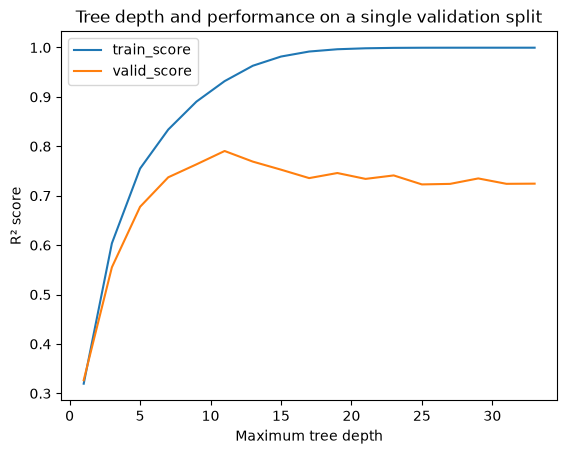

In [35]:
# Plot the scores collected above.
results_single_valid_df.plot(
    xlabel="Maximum tree depth",
    ylabel="R² score",
    title="Tree depth and performance on a single validation split",
)
plt.show()

### Read the plot together

- Where do you see evidence of underfitting or overfitting? Use both scores.
- Does extra depth always improve validation performance?
- Which depth would you choose?
- Would another validation split lead to the same choice?

In [36]:
# TODO: try this step before reading the worked solution below.
# What depth gives the "best" validation score?
best_depth = results_single_valid_df['valid_score'].idxmax() 
best_depth

np.int64(11)

## Would another split tell the same story?

**Slide pause:** five-fold cross-validation. Each configuration is fitted five times, with a different fold held out each time.

**TODO:** compare the same depths with five-fold CV on `X_train, y_train`. Record mean training score, mean validation score, and validation-score standard deviation.

Before running:
- Does `test_score` in `cross_validate` mean our final test set?
- How many fits will 17 candidate depths require?
- Why use `X_train` rather than the smaller `X_tr`?

In [37]:
depths = np.arange(1, 35, 2)
depths

array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33])

In [38]:
# TODO: compare depths using five-fold CV (worked solution below).
cv_train_scores = []
cv_valid_scores = []
cv_valid_stds = []

for depth in depths:
    dt = DecisionTreeRegressor(max_depth=depth, random_state=RANDOM_STATE)
    results = cross_validate(
        dt, X_train, y_train, return_train_score=True
    )
    cv_train_scores.append(results['train_score'].mean())
    # Here test_score refers to validation folds, not X_test.
    cv_valid_scores.append(results['test_score'].mean())
    cv_valid_stds.append(results['test_score'].std())

In [39]:
cv_results_df = pd.DataFrame({
    "train_score": cv_train_scores,
    "valid_score": cv_valid_scores,
    "valid_std": cv_valid_stds,
}, index=depths)
cv_results_df.index.name = "max_depth"
cv_results_df

,train_score,valid_score,valid_std
max_depth,,,
1,0.321050,0.322465,0.026939
3,0.603243,0.559284,0.017880
5,0.752169,0.688484,0.015447
7,0.835876,0.758259,0.025574
9,0.894960,0.768184,0.019748
11,0.938201,0.772185,0.022939
13,0.966812,0.760966,0.011522
15,0.983340,0.754620,0.017938
17,0.992220,0.730025,0.036612


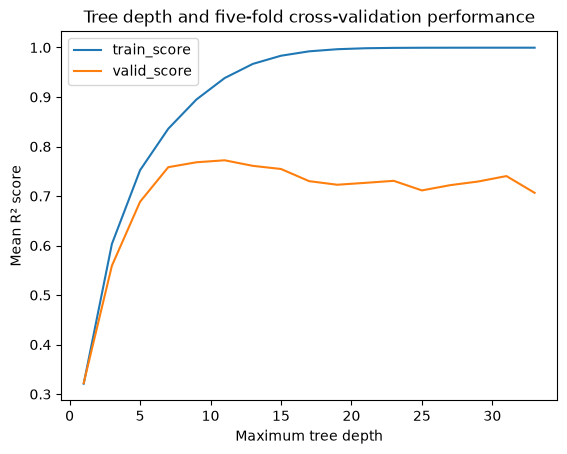

In [40]:
cv_results_df[["train_score", "valid_score"]].plot(
    xlabel="Maximum tree depth",
    ylabel="Mean R² score",
    title="Tree depth and five-fold cross-validation performance",
)
plt.show()

**TODO:** find the depth with the highest mean CV score. Is a tiny improvement enough to prefer a much deeper tree?

In [41]:
# TODO: try this step before reading the worked solution below.
best_depth = cv_results_df['valid_score'].idxmax()
best_depth

np.int64(11)

### ❓❓ Questions for you

**Discuss the following questions with your neighbour**

- How does this comparison differ from the single validation split?
- How much do validation scores vary across folds? How does that affect your confidence in small differences between depths?
- If a shallower tree scores nearly as well as the highest-scoring tree, which would you choose? Explain.
- Have we found the best possible depth, or the best choice according to a particular comparison?

## Refit the selected configuration and evaluate

**Before running:** fix your chosen depth and explain why you chose it.

**TODO:** fit a fresh tree on **all non-test training data**, then evaluate it on the test set. Why do we refit instead of keeping one of the CV models?

In a fresh workflow, this would be our first look at test performance. **Here, we already used these data during EDA and model comparisons, so this score is illustrative—not an independent final estimate.** A new independent evaluation would be needed for that claim.

In [42]:
# TODO: record your choice before looking at the final score.
selected_depth = int(best_depth)
selection_reason = "Highest mean validation R² among the depths compared with CV."
print(f"Selected depth: {selected_depth}. {selection_reason}")

# Refit on all non-test training data.
dt_final = DecisionTreeRegressor(max_depth=selected_depth, random_state=RANDOM_STATE)
dt_final.fit(X_train, y_train)
dt_final.score(X_train, y_train)

Selected depth: 11. Highest mean validation R² among the depths compared with CV.


0.9308647034083802

In [43]:
# TODO: try this step before reading the worked solution below.
# Evaluate on the test set
dt_final.score(X_test, y_test)

0.7784948928666875

How does this score compare with the CV estimate? What might explain a difference?

If we now changed the depth because of this score, which role would the test set be playing?

## Optional: what features did the tree use?

In [44]:
#What's the depth of the model? 
dt_final.get_depth()

11

In [45]:
# plot_tree(dt_final, feature_names = X_train.columns.tolist(), impurity=False, filled=True);

In [46]:
# Which features are the most important ones?
dt_final.feature_importances_

array([0.00080741, 0.00327551, 0.25123925, 0.01808825, 0.00079645,
       0.03213916, 0.01190633, 0.00106308, 0.36400802, 0.02313684,
       0.00295235, 0.01209545, 0.00064647, 0.17216105, 0.06835056,
       0.02416048, 0.01317334])

**TODO:** pair each importance with its feature name and sort the table. Which features does this tree rely on most?

These are impurity-based importances for this fitted tree. They do not establish causation; correlated features can share importance, and features with many possible splits can be favoured. If this exploration motivates another modeling choice, return to validation.

In [47]:
# TODO: try this step before reading the worked solution below.
df = pd.DataFrame( 
    data = {
        "features": dt_final.feature_names_in_,
        "feature_importances": dt_final.feature_importances_
    }
)
df.sort_values("feature_importances", ascending=False)

,features,feature_importances
8,grade,0.364008
2,sqft_living,0.251239
13,lat,0.172161
14,long,0.068351
5,waterfront,0.032139
15,sqft_living15,0.024160
9,sqft_above,0.023137
3,sqft_lot,0.018088
16,sqft_lot15,0.013173
11,yr_built,0.012095


## Looking back: what did we learn?

Discuss with a neighbour:

1. Why wasn't the initial training score enough?
2. When did our test set start influencing model selection?
3. Why didn't creating a validation set later undo that?
4. What did CV add beyond one validation split?
5. Where did you see underfitting or overfitting?

## The workflow to take away

On a **fresh project**:

1. Define the prediction task and reserve a test set using an appropriate split.
2. Explore the **training data** and prepare features.
3. Establish a baseline; compare models and hyperparameters using **CV on the training data**. Learn any preprocessing within each training fold.
4. Fix the configuration and **refit on all training data**.
5. Evaluate on the **untouched test set**.
6. Optionally inspect feature importances to understand the fitted model.

**The golden rule:** test data must not guide training or model selection.

Our opening shortcuts helped us discover this workflow. They are not steps to copy into a final evaluation.